# 2.6 — Images ARE matrices

Worksheet first (yes, even for this one). Then come back and paint with algebra.
Every image below is built from raw numpy — no photos, no files, just arrays.

One new tool: `plt.imshow(matrix, cmap="gray", vmin=0, vmax=1)` displays a matrix *as a picture*
(gray colour scale, 0 = black, 1 = white).

In [1]:
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", ax=None):
    """Display a matrix as an image. Grayscale if 2-D, colour if (h, w, 3)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(3.5, 3.5))
    if img.ndim == 2:                                   # .ndim: 2 = grayscale matrix
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    else:
        ax.imshow(np.clip(img, 0, 1))
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    return ax

shape: (100, 100) — 100 rows, 100 columns. It IS a matrix.


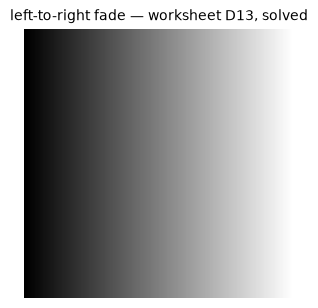

In [2]:
# Image 1: a gradient. One row fading 0 -> 1, stacked 100 times.
row = np.linspace(0, 1, 100)          # 100 evenly spaced numbers from 0 to 1
gradient = np.tile(row, (100, 1))     # np.tile = 'repeat this row, 100 rows x 1 copy across'

print("shape:", gradient.shape, "— 100 rows, 100 columns. It IS a matrix.")
show(gradient, "left-to-right fade — worksheet D13, solved")
plt.show()

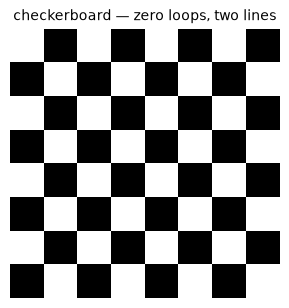

In [3]:
# Image 2: a checkerboard, painted purely with slice assignment.
# New syntax:  ::2 = 'every 2nd, starting at 0'    1::2 = 'every 2nd, starting at 1'
board = np.zeros((8, 8))
board[::2, ::2] = 1      # even rows, even columns -> white
board[1::2, 1::2] = 1    # odd rows, odd columns  -> white

show(board, "checkerboard — zero loops, two lines")
plt.show()
# Decode it against your worksheet D12 answer. Same board?

## Painting by indexing

Assigning to slices = painting rectangles. `img[2:4, 3:5] = 1` paints a 2×2 white block
at rows 2–3, columns 3–4. Remember: **row first, and row 0 is the top.**

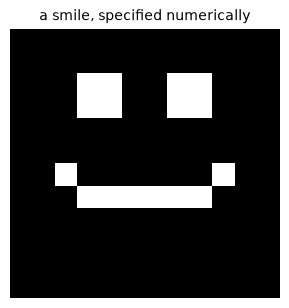

In [4]:
face = np.zeros((12, 12))

face[2:4, 3:5]  = 1.0     # left eye   (rows 2-3, cols 3-4)
face[2:4, 7:9]  = 1.0     # right eye
face[7, 3:9]    = 1.0     # mouth: one full row segment
face[6, 2]      = 1.0     # mouth corners, one pixel each — up a row
face[6, 9]      = 1.0

show(face, "a smile, specified numerically")
plt.show()

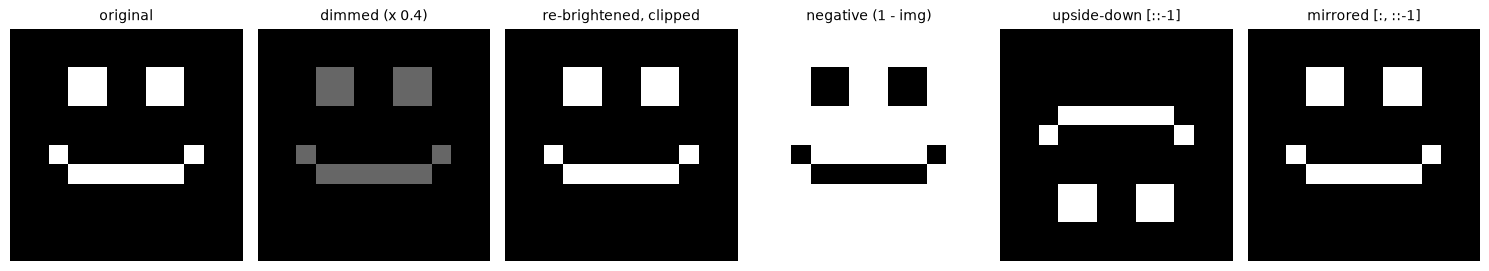

In [5]:
# The edits gallery: every photo-op is arithmetic you already own.
dim_face = face * 0.4                       # scalar multiply -> darker
edits = {
    "original": face,
    "dimmed (x 0.4)": dim_face,
    "re-brightened, clipped": np.clip(dim_face * 4, 0, 1),   # over-brighten, then clip to [0,1]
    "negative (1 - img)": 1 - face,
    "upside-down [::-1]": face[::-1],       # reverse the ROWS
    "mirrored [:, ::-1]": face[:, ::-1],    # reverse the COLUMNS
}

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax, (title, img) in zip(axes, edits.items()):
    show(img, title, ax=ax)
plt.tight_layout(); plt.show()

# YOUR TURN — build P from worksheet Part B with np.array and run your four edits
# (2P clipped, 1-P, flips, the crop P[0:2, 0:2]). show() each; check against your hand answers.

## Colour = three matrices wearing a trenchcoat

An RGB image is three grayscale matrices — red, green, blue — stacked into shape `(h, w, 3)`.
`np.stack([r, g, b], axis=-1)` does the stacking (`axis=-1` = "make the stack the *last* axis").

shape: (100, 100, 3) — (height, width, 3 colour channels)


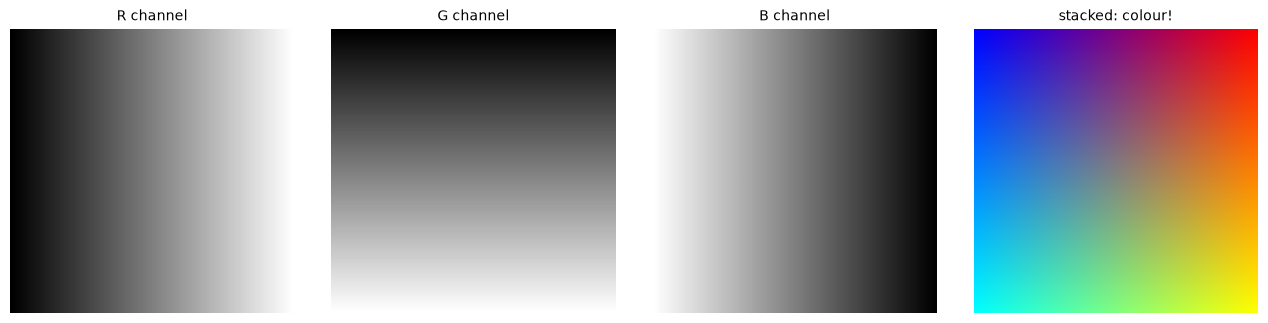

In [6]:
r = gradient                 # red grows left to right
g = gradient.T               # .T = transpose: the same fade, but top to bottom
b = 1 - gradient             # blue is red's negative

sunset = np.stack([r, g, b], axis=-1)
print("shape:", sunset.shape, "— (height, width, 3 colour channels)")

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
show(r, "R channel", ax=axes[0])
show(g, "G channel", ax=axes[1])
show(b, "B channel", ax=axes[2])
show(sunset, "stacked: colour!", ax=axes[3])
plt.tight_layout(); plt.show()

# YOUR TURN — three experiments:
# 1) sunset[:, :, 0] = 0   kills which colour? Predict, then show() it.
# 2) Give the smiley a coloured face: stack face with two edited copies of itself.
# 3) Random noise 'TV static': rng = np.random.default_rng(42); show(rng.random((100, 100)))

## 🌀 What you can now claim

Every photo ever taken, every frame of every film, every image stable diffusion has dreamed —
all of them are exactly the objects you manipulated today. When a vision model "looks" at a
picture, it dots patches of that matrix against learned pattern-matrices (lesson 2.6's deep-end
question — that's a *convolution*, arriving in Module 5). When stable diffusion generates one,
it starts from the TV-static you just made and edits it, step by step, with arithmetic.

Matrices in, beauty out. You have the whole vocabulary now.

---
*This module's boss awaits: `worksheets/07-boss-linear-algebra.md` — hand parts cold, then the
numpy darkroom project. Clear the boss and the Mandelbrot set is your reward.*